In [1]:
cd tumbling_git/

/share/nas2/pryder/tumbling_git


In [2]:
from unpack_vdif import unpacksamps, sortframes, readframes, readheader
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from scipy.ndimage import shift
from schedule_utils import range_finder_general
from skyfield.api import load, EarthSatellite, wgs84
# %load_ext jupyternotify
from scipy.signal import find_peaks
from scipy.ndimage import shift as imshift
from pc_utils import rect, signal_samp_to_dB
import plotly.express as px

In [3]:
#inputting tle
tle_line_1 = '1 61995U 16053M   25035.62796428  .00000095  00000-0  00000-0 0  9998'
tle_line_2 = '2 61995   0.2642  88.1708 0053675 268.4745   3.2920  1.01033442  1106'
ts = load.timescale()
intelsat_tle = EarthSatellite(tle_line_1, tle_line_2, 'intelsat 33e', ts)

In [26]:
#input paramters
f1 = int(0)        
bw = int(8e6)        
Tp = 800e-6    
pri = 19.7e-3
freq = 1295e6
c= 299792458
samp_rate = 16e6
alpha = bw/Tp   #chirp rate
N = 100
infilename = '/share/nas2/pryder/SET_Observations_Test_1/Wednesday/vdifs/TSSat_20250205_lo1_1295MHz_intelsat33e.vdif'
pol_channel = 0

In [ ]:
#opens vdif
# takes about 20s to run
with open(infilename) as infile:
    header = readheader(infile)
    framedata, seconds, framenums, threads = readframes(infile, header)

threaddata = sortframes(framedata, seconds, framenums, threads)
pola = unpacksamps(threaddata[pol_channel,:], header['nbits'], header['dtype'])

In [17]:
# Convert to IQ. Add a phase that rotates every 4 samples
# takes ~20s to run
phase_4_samples = np.array([ 1+0j, 0-1j, -1+0j, 0+1j ])
phase_all_samples = np.tile(phase_4_samples, pola.size//4+1)  # +1 in case not divisible by 4
iq_samples_not_down = pola*phase_all_samples[:pola.size]

In [18]:
points = int(samp_rate*pri) #number of samples per pulse

height = 64 #coherent processing interval
padded_length = points * 2 -1

reduced_length = height * points #length for cpi that includes an integer number of pulses

startoffset = int(samp_rate*100)
pola_reduced = iq_samples_not_down[startoffset:startoffset+reduced_length]
dat = pola_reduced.reshape((height, points))
cdat_pc = np.zeros((height, padded_length), dtype=complex)

In [19]:
ts = load.timescale()
t_tle = ts.utc(2025, 2, 5, 13, 45)
range_rate_from_tle = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]

In [20]:
tau_dot = range_rate_from_tle/c #normalised range rate
k = np.arange(points)

In [21]:
t1=np.linspace(-Tp/2,Tp/2,points,endpoint=False)

baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)

chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 

envelope_term = rect((t1)/(Tp*(1+tau_dot)))
template = baseband_offset_term*chirp_term*envelope_term

In [22]:
# time taken for this to run depends on cpi length
# 32s cpi -> 3s
# 64s cpi -> 7-15s
# 2048s cpi -> 3mins 40s

for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
     received_pulse=dat[i]*phase_ramp[:points]
     signal1_fft = np.fft.fft(received_pulse, n=padded_length)
     signal2_fft = np.fft.fft(template, n=padded_length)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate())
     cdat_pc[i,:]=np.fft.fftshift(correlation2)

In [23]:
power = (np.abs(cdat_pc))**2
spec = np.sum(power, axis=0)

spec_dB = signal_samp_to_dB(spec, spec)
power_dB = signal_samp_to_dB(power, power)

## Uncorrected Incoherent Sum and RTI

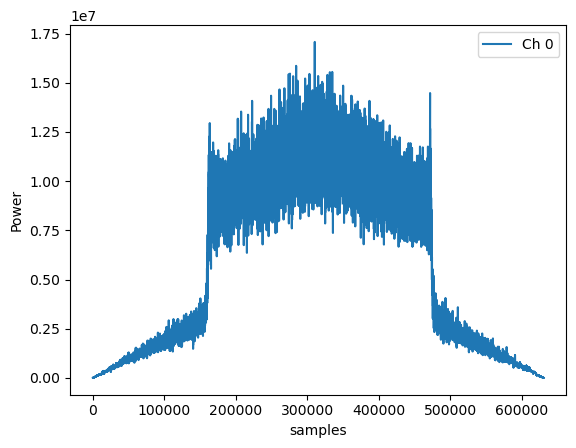

In [27]:
#incoherent sum
plt.plot(spec, label='Ch '+str(pol_channel))
plt.xlabel('samples')
plt.ylabel('Power')
plt.legend()
plt.show()

In [39]:
centre = int(padded_length/2)

In [56]:
np.argmax(spec)

np.int64(310292)

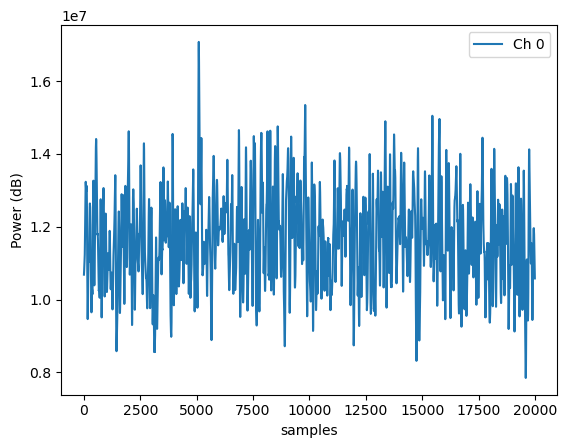

In [43]:
#incoherent sum
# samples range
# 64 cpi -> 91000:93000
# 2048 cpi -> 147500:148000
# 
plt.plot(spec[centre-10000:centre+10000], label='Ch 0')
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.legend()
plt.show()

In [45]:
centre-10000+4000

309199

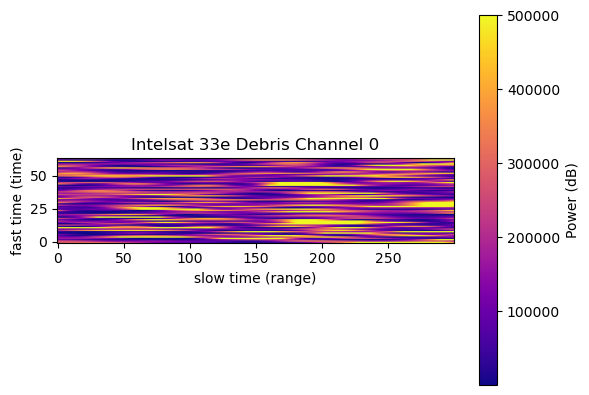

In [61]:
#rti
plt.imshow(power[:, 310092:310392], cmap = 'plasma', origin='lower', vmax=5e5)
plt.title('Intelsat 33e Debris Channel 0')
cbar= plt.colorbar()
cbar.set_label('Power (dB)', rotation=90)
plt.xlabel('slow time (range)')
plt.ylabel('fast time (time)')
plt.show()

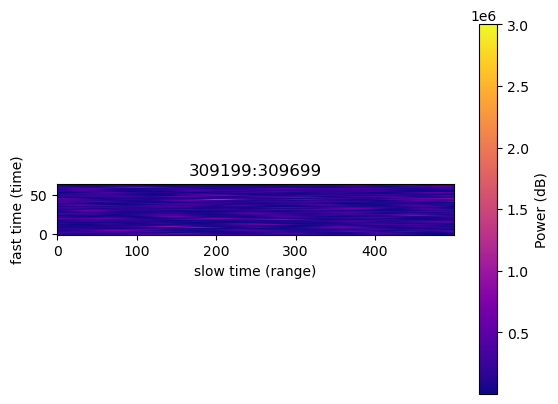

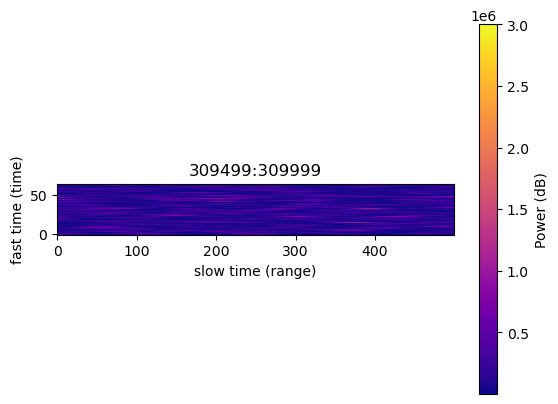

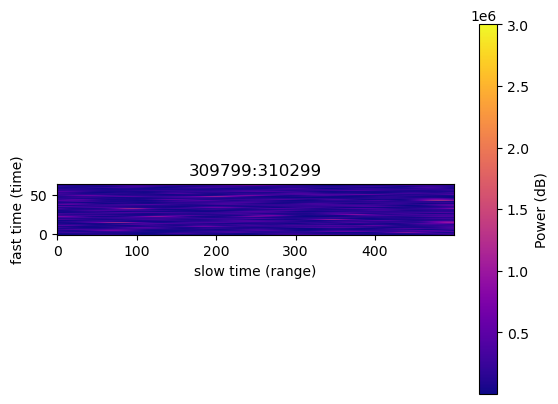

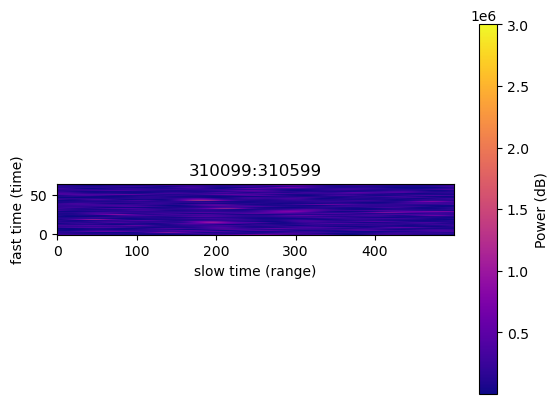

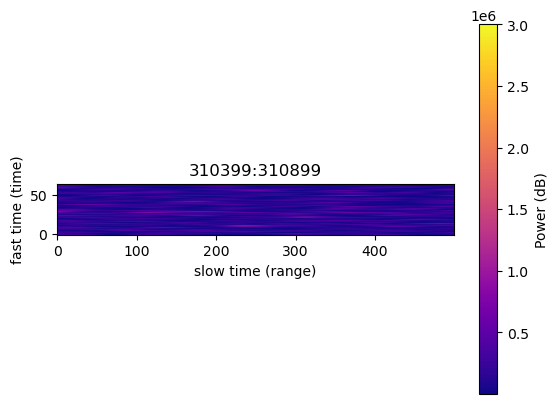

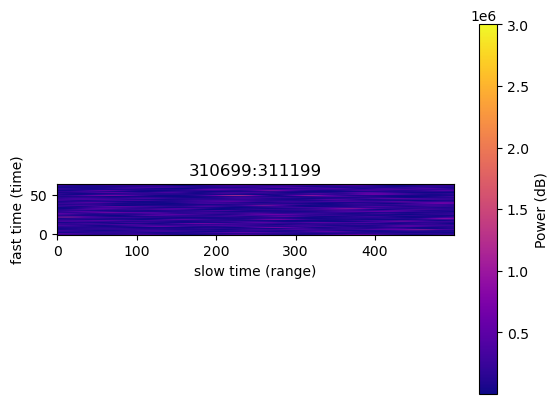

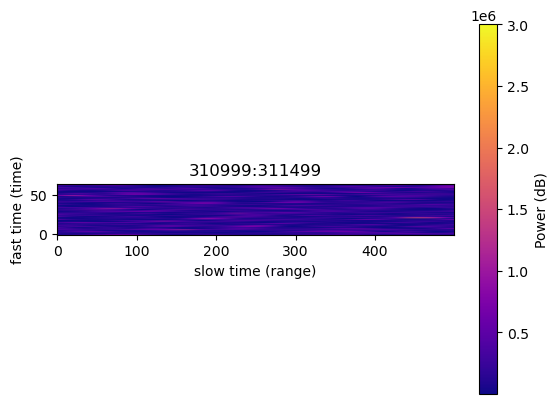

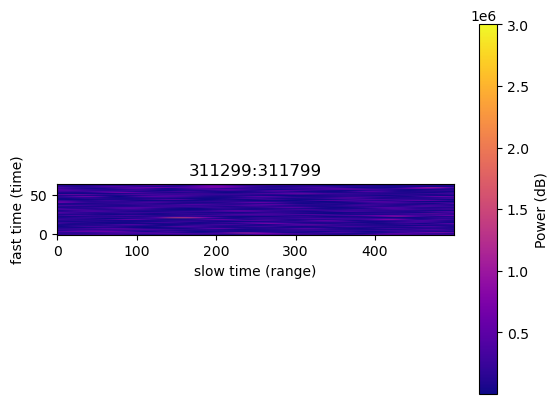

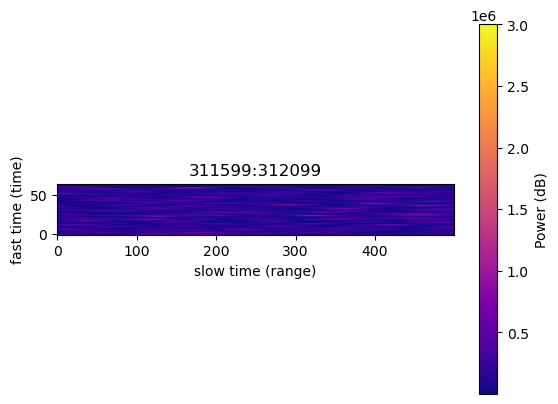

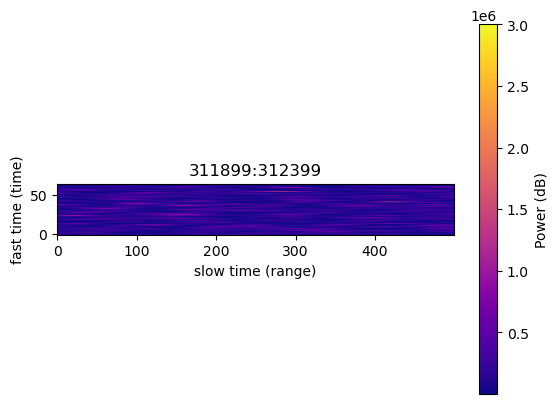

In [57]:
#rti
start = centre-10000+4000
end = start+500
for i in range(10):
    plt.imshow(power[:, start:end], vmax = 3e6,cmap = 'plasma', origin='lower')
    plt.title(str(start)+ ':'+ str(end))
    cbar= plt.colorbar()
    cbar.set_label('Power (dB)', rotation=90)
    plt.xlabel('slow time (range)')
    plt.ylabel('fast time (time)')
    plt.show()
    start += 300
    end+=300

## Range Migration Corrections

### No averaging

In [83]:
r_i = []
#this is the first correction
sub_power = power[:, 91700:92200]
time1 = np.arange(sub_power.shape[0])
data = sub_power.T

r = np.zeros(data.shape[1], dtype=int)
r[0] = np.argmax(np.abs(data[:, 1]))

window = 10

for i in range(1, data.shape[1]):
    prev = r[i-1]
    
    start = max(0, prev - window)
    end = min(data.shape[0], prev + window)
    segment = np.abs(data[start:end, i])
    # print(i)

    #local maximum
    r[i] = start + np.argmax(segment)

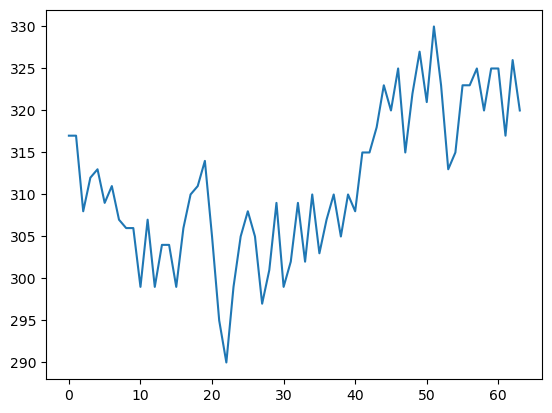

In [84]:
#plotting range per pulse 
plt.plot(time1, r)
plt.show()

### Averaging Pulse together

In [115]:
r_i = []
sub_power = power
time1 = np.arange(sub_power.shape[0])
data = sub_power.T

r = np.zeros(data.shape[1], dtype=int)
r[0] = np.argmax(np.abs(data[:, 1]))

window = 10

num_pulses_combined = 4

avgd_length = int(data.shape[1]/num_pulses_combined)
j=0
for i in range(1, avgd_length):
    print(j)
    prev = r[i-1]
    
    start = max(0, prev - window)
    end = min(data.shape[0], prev + window)
    pre_segment = data[start:end, j:j+num_pulses_combined]
    segment = np.abs(np.average(pre_segment, axis=1))

    #local maximum
    r[i] = start + np.argmax(segment)
    j+=num_pulses_combined

0
4
8
12
16
20
24
28
32
36
40
44
48
52
56


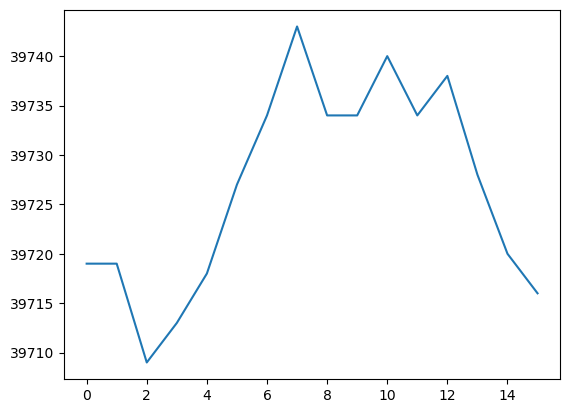

In [116]:
#plotting range per pulse type 
plt.plot(time1[0:16], r[0:16])
plt.show()

In [117]:
#expanding average correction to be correction for every pulse
r_expanded = []
for x in r[0:avgd_length]:
    for y in range(num_pulses_combined):
        r_expanded.append(x)

for z in range(height-len(r_expanded)):
    r_expanded.append(x)

### Applying the motion compensation

In [118]:
coeffs = np.polyfit(time1, r_expanded, 2)   #2 is quadratic fit, 8 is ridiculous!
r_fit = np.polyval(coeffs, time1)

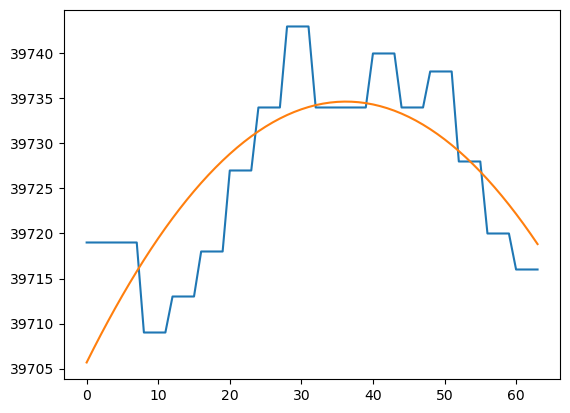

In [119]:
#plotting fit
plt.plot(time1, r_expanded)
plt.plot(time1, r_fit)
plt.show()

In [104]:
r_ref = r_fit[len(r_fit)//2]
rmc_shift = r_fit-r_ref

In [105]:
#takes about 3 minutes
corrected = np.zeros_like(cdat_pc)
for i in range(height):
    corrected[i, :] = imshift(cdat_pc[i, :], -rmc_shift[i])

In [106]:
power_corrected = (np.abs(corrected))**2
spec_corrected = np.sum(power_corrected, axis=0)

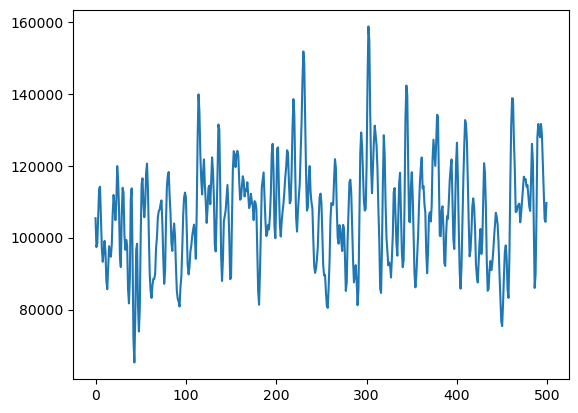

In [107]:
plt.plot(spec_corrected[91700:92200], label='Ch 1')
plt.show()

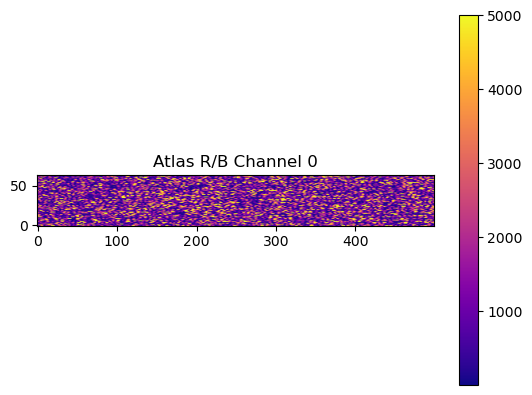

In [109]:
plt.imshow(power_corrected[:, 91700:92200], vmax = 5000, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
plt.colorbar()
plt.show()

## Making a Spectrogram

In [123]:
cpi_jump_samples = int(reduced_length/4)

# if doing successive cpis, this is the maximum number of strips you can get in your spectrogram
# now edited so it will be universal max (i think) - but for small increments this will be very large - don't run 10 million!
n_max_successive = int(np.floor((len(pola) - startoffset - 1- reduced_length)/reduced_length))
n_max_window = int(np.floor((len(pola)-startoffset-reduced_length)/cpi_jump_samples))

# if doing one sample difference, then n_max is very large 

number_of_strips_in_spectrogram = n_max_window

spectrogram = np.zeros((height, number_of_strips_in_spectrogram))

In [124]:
# %%notify -m "Spectrogram generated..."
#looping over successive cpis to generate spectrogram
peak_range_history = []
peak_doppler_history = []
for n in range(number_of_strips_in_spectrogram):
    print("strip ", n, " of ", number_of_strips_in_spectrogram)
    # start_index = startoffset + (n*reduced_length)
    # end_index = startoffset + ((n+1)*reduced_length)
    start_index = cpi_jump_samples*n + startoffset
    end_index = cpi_jump_samples*(n+1)+ reduced_length + startoffset - cpi_jump_samples

    print('which covers samples ', start_index, " to ", end_index)
    pola_reduced = iq_samples_not_down[start_index:end_index]
    dat = pola_reduced.reshape((height, points))
    # dat = dat.astype(float)-1.5
    # dat = dat - np.mean(dat, axis=1, keepdims=True)
    # cdat = dat.astype(complex)
    cdat_pc = np.zeros_like(dat)

    for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=dat[i]
     template = baseband_offset_term*chirp_term*envelope_term
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     # correlation2_in_fd = np.fft.fft(correlation2)
     # timing_difference = estimate_delta_phase(correlation2, samp_rate)
     # digital_timing = np.exp(2j*np.pi*k*samp_rate*timing_difference) #peak not centred in discrete time interval correction
     # correlation3 = correlation2_in_fd * digital_timing
     # correlation3 = np.fft.ifft(correlation3)
     cdat_pc[i,:]=correlation2

    power = (np.abs(cdat_pc))**2

    r_i = []
    time1 = np.arange(power.shape[0])
    data = power.T

    r = np.zeros(data.shape[1], dtype=int)
    r[0] = np.argmax(np.abs(data[:, 1]))

    window = 10

    num_pulses_combined = 4

    avgd_length = int(data.shape[1]/num_pulses_combined)
    j=0
    for i in range(1, avgd_length):
        # print(j)
        prev = r[i-1]
        
        start = max(0, prev - window)
        end = min(data.shape[0], prev + window)
        pre_segment = data[start:end, j:j+num_pulses_combined]
        segment = np.abs(np.average(pre_segment, axis=1))

        #local maximum
        r[i] = start + np.argmax(segment)
        j+=num_pulses_combined
    
    #expanding average correction to be correction for every pulse
    r_expanded = []
    for x in r[0:avgd_length]:
        for y in range(num_pulses_combined):
            r_expanded.append(x)

    for z in range(height-len(r_expanded)):
        r_expanded.append(x)

    coeffs = np.polyfit(time1, r_expanded, 2)   #2 is quadratic fit, 8 is ridiculous!
    r_fit = np.polyval(coeffs, time1)
    r_ref = r_fit[len(r_fit)//2]
    rmc_shift = r_fit - r_ref
    corrected = np.zeros_like(cdat_pc)

    corrected[:, i] = imshift(cdat_pc[:, i], -rmc_shift[i])

    print('Finished pulse compression')
    unshifted_range_doppler = np.fft.fft(cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)
    rd_abs = np.abs(range_doppler ** 2)
    rd_abs_reduced = rd_abs[:, :]
    peaks = np.sum(rd_abs_reduced, axis = 0)
    peak = np.argmax(peaks)
    strip = rd_abs_reduced[:, peak:peak+1]
    print('Peak index: ', peak)
    # print(spectrogram[:, n:n+1])
    spectrogram[:, n:n+1] = strip
    peak_range_history.append(peak)
    # print(strip)
    # print(spectrogram[:, n:n+1])

strip  0  of  526
which covers samples  1600000000  to  1620172800
Finished pulse compression
Peak index:  91930
strip  1  of  526
which covers samples  1605043200  to  1625216000
Finished pulse compression
Peak index:  60922
strip  2  of  526
which covers samples  1610086400  to  1630259200
Finished pulse compression
Peak index:  175268
strip  3  of  526
which covers samples  1615129600  to  1635302400
Finished pulse compression
Peak index:  147774
strip  4  of  526
which covers samples  1620172800  to  1640345600
Finished pulse compression
Peak index:  147774
strip  5  of  526
which covers samples  1625216000  to  1645388800
Finished pulse compression
Peak index:  120199
strip  6  of  526
which covers samples  1630259200  to  1650432000
Finished pulse compression
Peak index:  120199
strip  7  of  526
which covers samples  1635302400  to  1655475200
Finished pulse compression
Peak index:  37307
strip  8  of  526
which covers samples  1640345600  to  1660518400
Finished pulse compressi

: 

: 

: 

In [ ]:
#only needed to save numpy array
np.save('./atlas_64overlap.npy', spectrogram)
#only needed if loading in previously saved spectrogram array
spectrogram = np.load('atlas_64overlap.npy')

In [ ]:
plt.imshow(spectrogram[:, :], vmax=3e7, origin='lower')#, extent = [time_labels[0], time_labels[-1], 0, 19], aspect='auto')
plt.xlabel('Time samples')
plt.ylabel ('range rate samples')
# plt.vlines((80, 92), 0, 39, 'r')
# plt.colorbar()
plt.show()

# Try again

In [1]:
cd tumbling_git/

/share/nas2/pryder/tumbling_git


In [3]:
from unpack_vdif import unpacksamps, sortframes, readframes, readheader
import numpy as np
import matplotlib.pyplot as plt
from schedule_utils import range_finder_general
from skyfield.api import load, EarthSatellite
from pc_utils import rect

# getting original signal and spectrum

#inputting tle
tle_line_1 = '1 61995U 16053M   25035.62796428  .00000095  00000-0  00000-0 0  9998'
tle_line_2 = '2 61995   0.2642  88.1708 0053675 268.4745   3.2920  1.01033442  1106'
ts = load.timescale()
intelsat_tle = EarthSatellite(tle_line_1, tle_line_2, 'intelsat 33e', ts)

#input paramters
f1 = int(0)        
bw = int(8e6)        
Tp = 800e-6    
pri = 19.7e-3
freq = 1295e6
c= 299792458
samp_rate = 16e6
alpha = bw/Tp   #chirp rate
N = 100
infilename = '/share/nas2/pryder/SET_Observations_Test_1/Wednesday/vdifs/TSSat_20250205_lo1_1295MHz_intelsat33e.vdif'
pol_channel = 0

#opens vdif
with open(infilename) as infile:
    header = readheader(infile)
    framedata, seconds, framenums, threads = readframes(infile, header)
threaddata = sortframes(framedata, seconds, framenums, threads)
pola = unpacksamps(threaddata[pol_channel,:], header['nbits'], header['dtype'])
print('VDIF opened.')

# Convert to IQ. Add a phase that rotates every 4 samples
phase_4_samples = np.array([ 1+0j, 0-1j, -1+0j, 0+1j ])
phase_all_samples = np.tile(phase_4_samples, pola.size//4+1)  # +1 in case not divisible by 4
iq_samples_not_down = pola*phase_all_samples[:pola.size]
print('Converted into IQ samples.')

# reshaping into pulse repetition intervals
points = int(samp_rate*pri) #number of samples per pulse
height = 128 #coherent processing interval
reduced_length = height*points #length for cpi that includes an integer number of pulses
startoffset = int(samp_rate*100)

VDIF opened.
Converted into IQ samples.


In [5]:
cpi_jump_samples = int(reduced_length/4)

# if doing successive cpis, this is the maximum number of strips you can get in your spectrogram
# now edited so it will be universal max (i think) - but for small increments this will be very large - don't run 10 million!
n_max_successive = int(np.floor((len(pola) - startoffset - 1- reduced_length)/reduced_length))
n_max_window = int(np.floor((len(pola)-startoffset-reduced_length)/cpi_jump_samples))

# if doing one sample difference, then n_max is very large 

number_of_strips_in_spectrogram = n_max_window

spectrogram = np.zeros((height, number_of_strips_in_spectrogram))
rcm = np.zeros((320, number_of_strips_in_spectrogram))

#getting range rate for template pulse
ts = load.timescale()
t_tle = ts.utc(2026, 2, 18, 14, 50)
range_rate_from_tle = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]
tau_dot = range_rate_from_tle/c #normalised range rate
k = np.arange(points)

In [7]:
peak_range_history = []
peak_doppler_history = []

strip  0  of  261
which covers samples  1600000000  to  1640345600
time for tle is  2025-02-05T13:45:00Z
Template pulse made.
Pulse compression complete


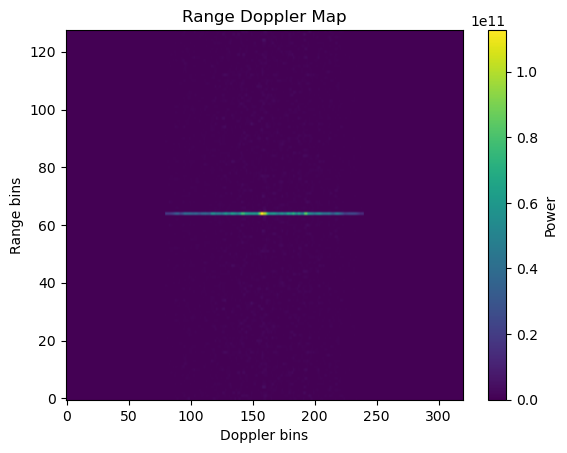

Peak index:  158
strip  1  of  261
which covers samples  1610086400  to  1650432000
time for tle is  2025-02-05T13:45:01Z
Template pulse made.
Pulse compression complete


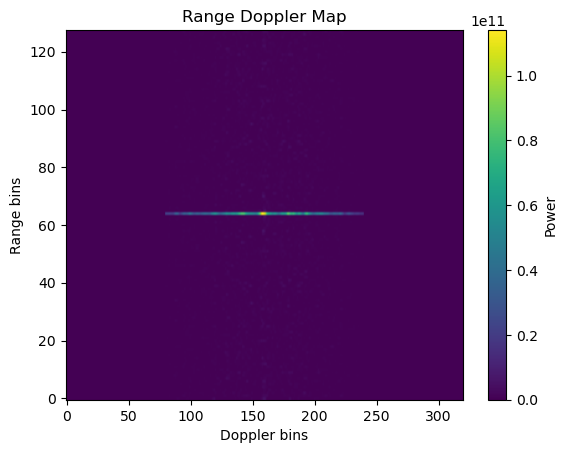

Peak index:  159
strip  2  of  261
which covers samples  1620172800  to  1660518400
time for tle is  2025-02-05T13:45:01Z
Template pulse made.
Pulse compression complete


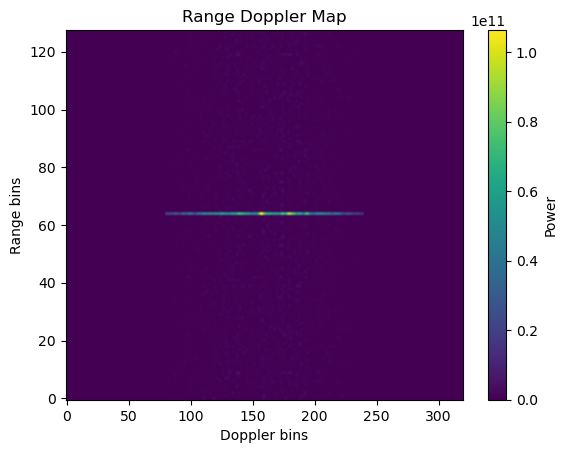

Peak index:  174
strip  3  of  261
which covers samples  1630259200  to  1670604800
time for tle is  2025-02-05T13:45:02Z
Template pulse made.
Pulse compression complete


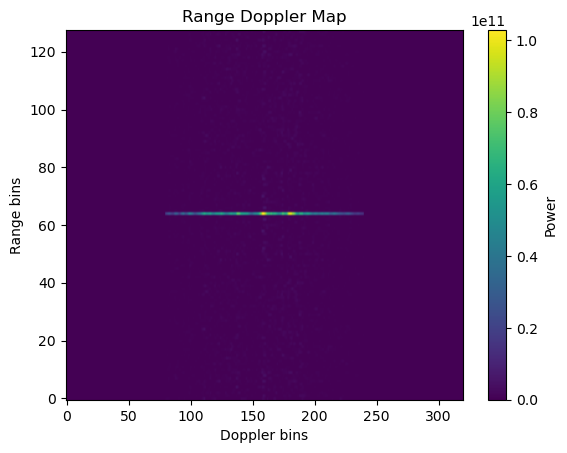

Peak index:  159
strip  4  of  261
which covers samples  1640345600  to  1680691200
time for tle is  2025-02-05T13:45:03Z
Template pulse made.
Pulse compression complete


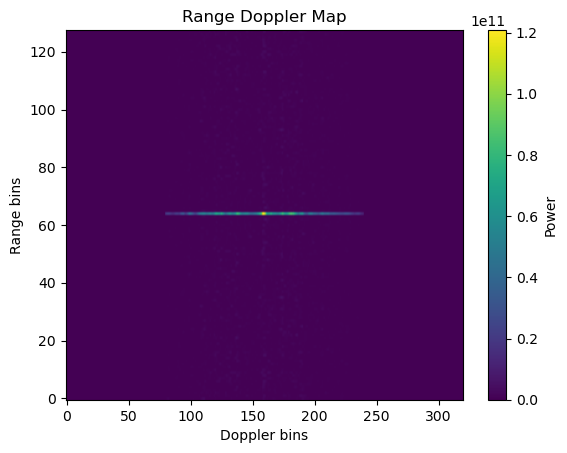

Peak index:  159
strip  5  of  261
which covers samples  1650432000  to  1690777600
time for tle is  2025-02-05T13:45:03Z
Template pulse made.
Pulse compression complete


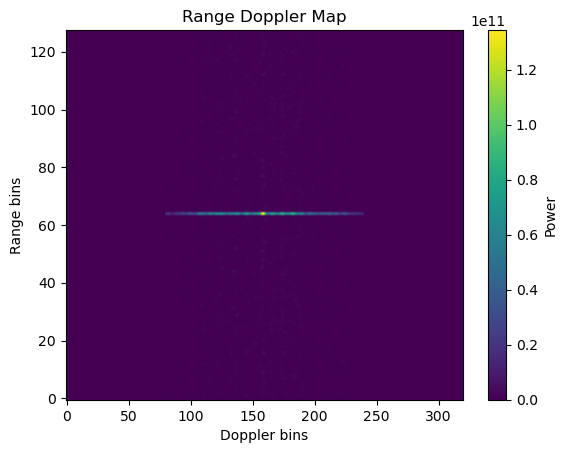

Peak index:  158
strip  6  of  261
which covers samples  1660518400  to  1700864000
time for tle is  2025-02-05T13:45:04Z
Template pulse made.
Pulse compression complete


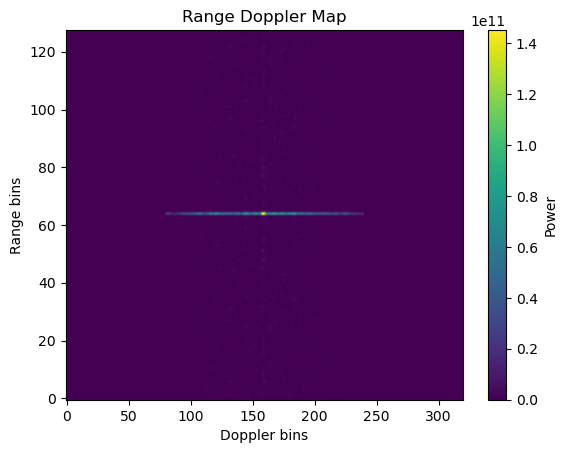

Peak index:  158
strip  7  of  261
which covers samples  1670604800  to  1710950400
time for tle is  2025-02-05T13:45:04Z
Template pulse made.
Pulse compression complete


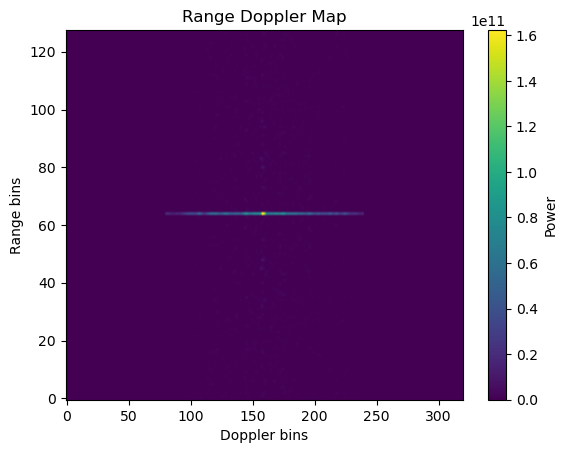

Peak index:  158
strip  8  of  261
which covers samples  1680691200  to  1721036800
time for tle is  2025-02-05T13:45:05Z
Template pulse made.
Pulse compression complete


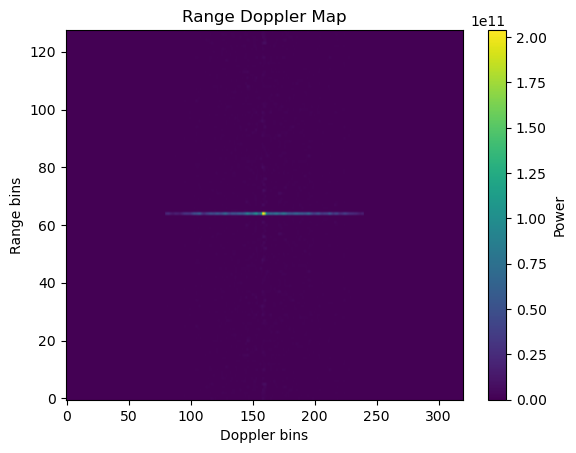

Peak index:  159
strip  9  of  261
which covers samples  1690777600  to  1731123200
time for tle is  2025-02-05T13:45:06Z
Template pulse made.
Pulse compression complete


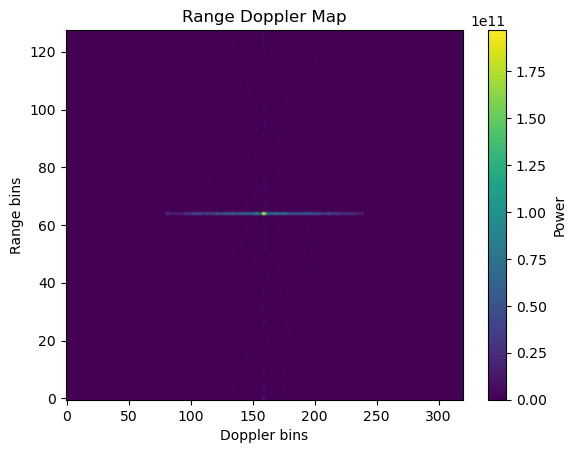

Peak index:  159
strip  10  of  261
which covers samples  1700864000  to  1741209600
time for tle is  2025-02-05T13:45:06Z
Template pulse made.
Pulse compression complete


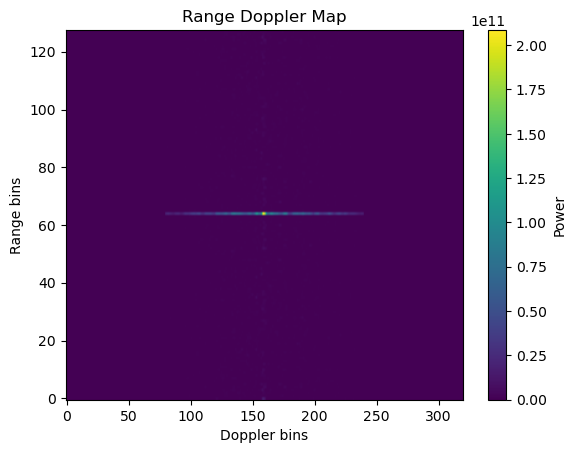

Peak index:  159
strip  11  of  261
which covers samples  1710950400  to  1751296000
time for tle is  2025-02-05T13:45:07Z
Template pulse made.
Pulse compression complete


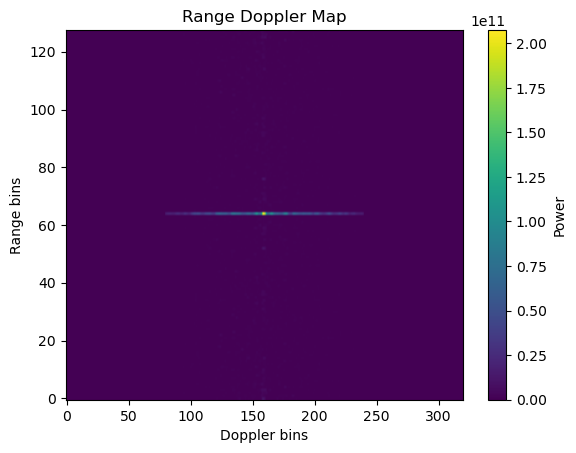

Peak index:  159
strip  12  of  261
which covers samples  1721036800  to  1761382400
time for tle is  2025-02-05T13:45:08Z
Template pulse made.
Pulse compression complete


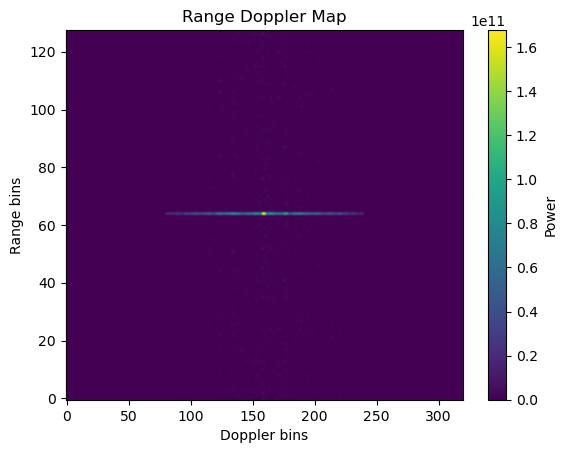

Peak index:  159
strip  13  of  261
which covers samples  1731123200  to  1771468800
time for tle is  2025-02-05T13:45:08Z
Template pulse made.
Pulse compression complete


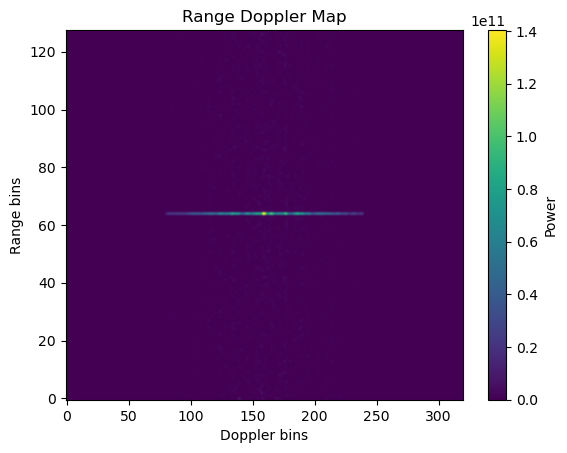

Peak index:  159
strip  14  of  261
which covers samples  1741209600  to  1781555200
time for tle is  2025-02-05T13:45:09Z
Template pulse made.
Pulse compression complete


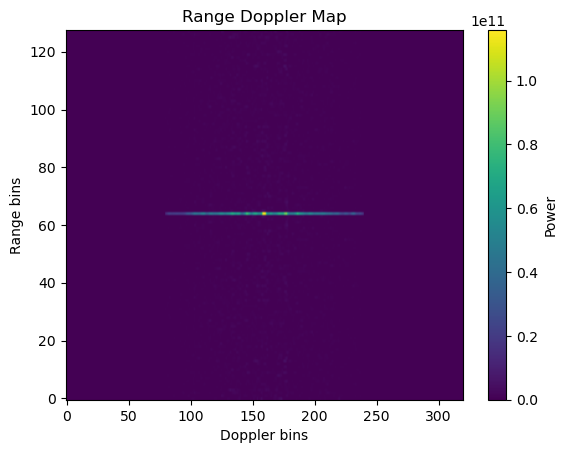

Peak index:  177
strip  15  of  261
which covers samples  1751296000  to  1791641600
time for tle is  2025-02-05T13:45:09Z
Template pulse made.
Pulse compression complete


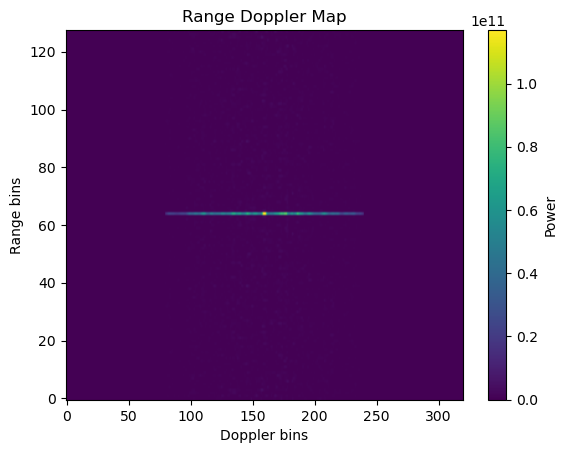

Peak index:  159
strip  16  of  261
which covers samples  1761382400  to  1801728000
time for tle is  2025-02-05T13:45:10Z
Template pulse made.
Pulse compression complete


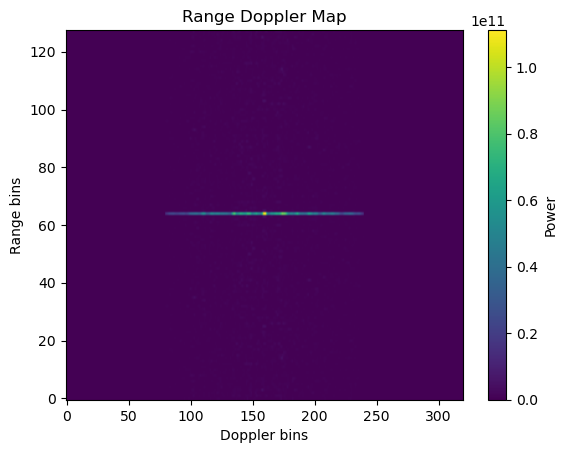

Peak index:  159
strip  17  of  261
which covers samples  1771468800  to  1811814400
time for tle is  2025-02-05T13:45:11Z
Template pulse made.
Pulse compression complete


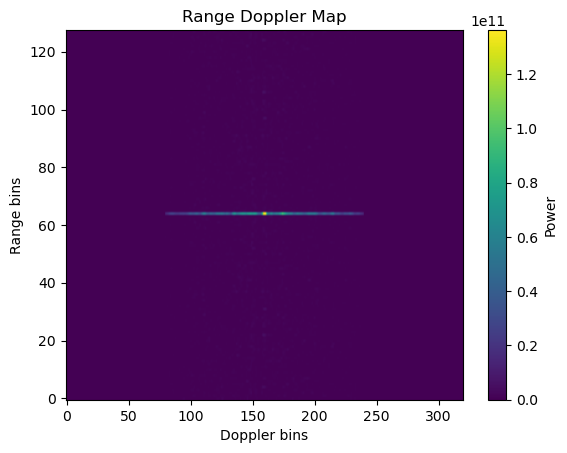

Peak index:  160
strip  18  of  261
which covers samples  1781555200  to  1821900800
time for tle is  2025-02-05T13:45:11Z
Template pulse made.
Pulse compression complete


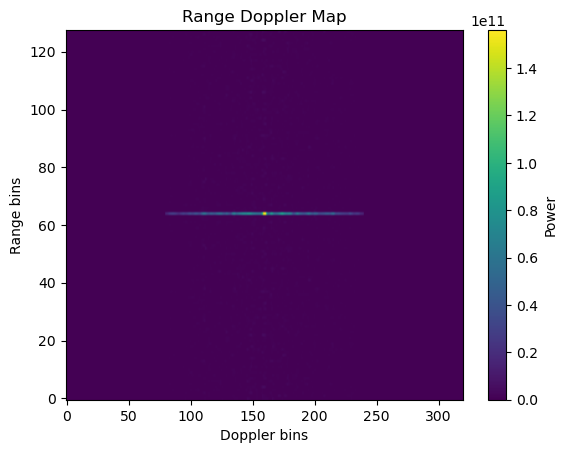

Peak index:  160
strip  19  of  261
which covers samples  1791641600  to  1831987200
time for tle is  2025-02-05T13:45:12Z
Template pulse made.
Pulse compression complete


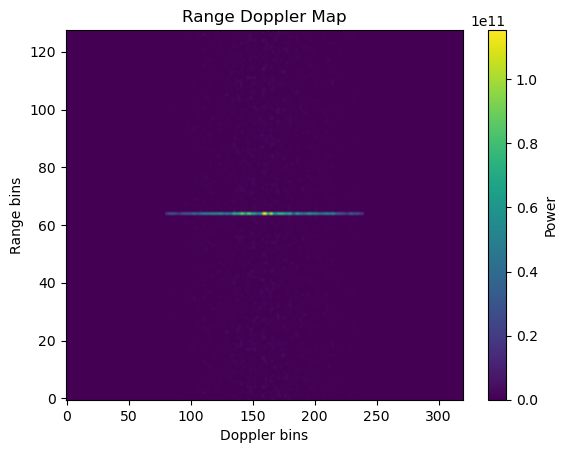

Peak index:  160


In [16]:
for n in range(20):
    
    print("strip ", n, " of ", number_of_strips_in_spectrogram)
    cdat_pc = np.zeros((height, points), dtype=complex)
    start_index = cpi_jump_samples*n + startoffset
    end_index = cpi_jump_samples*(n+1)+ reduced_length + startoffset - cpi_jump_samples
    print('which covers samples ', start_index, " to ", end_index)
    pola_reduced = iq_samples_not_down[start_index:end_index]
    dat = pola_reduced.reshape((height, points))
    #getting range rate for template pulse
    ts = load.timescale()
    s = (cpi_jump_samples/16e6)*n
    t_tle = ts.utc(2025, 2, 5, 13, 45, s)
    print('time for tle is ', t_tle.utc_iso())
    range_rate_from_tle = range_finder_general(intelsat_tle, t_tle, 'lovell')[1]
    tau_dot = range_rate_from_tle/c #normalised range rate
    k = np.arange(points)
    t1=np.linspace(0,pri,points,endpoint=False)
    baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)
    chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 
    envelope_term = rect((t1)/(Tp*(1+tau_dot)))
    template = baseband_offset_term*chirp_term*envelope_term
    print('Template pulse made.')

    #doing pulse compression
    for i in range(height):
        start_sec=i*pri
        end_sec=(i+1)*pri
        t=np.linspace(start_sec,end_sec,points,endpoint=False)
        received_pulse=dat[i]
        phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
        signal1_fft = np.fft.fft(received_pulse)
        signal2_fft = np.fft.fft(template)
        correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
        cdat_pc[i,:]=correlation2
    print('Pulse compression complete')

    power = (np.abs(cdat_pc))**2
    spectrum = np.sum(power, axis=0)
    # plt.plot(spectrum)
    # plt.show()
    # print(np.argmax(spectrum))

    freqs = np.fft.fftshift(np.fft.fftfreq(points, (1/samp_rate)))

    spectrum_peak = 147775 #np.argmax(spectrum)

    lower = spectrum_peak - 80
    upper = spectrum_peak + 80

    power_detection = power[:, lower:upper].T

    power_detection_padded = np.zeros((power_detection.shape[0]+160, power_detection.shape[1]))
    for i in range(power_detection.shape[1]):
        power_detection_padded[:, i] = np.pad(power_detection[:, i], (160//2, 160//2), mode='constant')

    window = np.hanning(power_detection_padded.shape[0])
    power_detection_p_and_w = np.zeros_like(power_detection_padded)
    for i in range(power_detection_padded.shape[1]):
        power_detection_p_and_w[:, i] = power_detection_padded[:, i] * window

    unshifted_range_doppler = np.fft.fft(power_detection_p_and_w.T, axis=0)
    range_doppler_map = np.fft.fftshift(unshifted_range_doppler, axes=0)
    rd_abs = np.abs(range_doppler_map ** 2)
    plt.imshow(rd_abs, origin='lower', aspect='auto')
    plt.title('Range Doppler Map')
    plt.xlabel('Doppler bins')
    plt.ylabel('Range bins')
    plt.colorbar(label='Power')
    plt.show()

    peaks = np.sum(rd_abs, axis = 0)
    peak = np.argmax(peaks)
    strip = rd_abs[:, peak:peak+1]
    print('Peak index: ', peak)
    peak_range_history.append(peak)
    # print(spectrogram[:, n:n+1])
    spectrogram[:, n:n+1] = strip
    peaks_r = np.sum(rd_abs, axis = 1)
    peak_r = np.argmax(peaks_r)
    strip_r = rd_abs[peak_r:peak_r+1, :]
    rcm[:, n:n+1] = strip_r.T

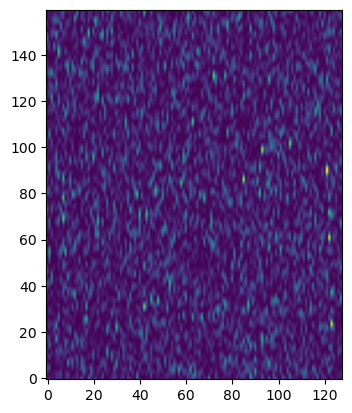

In [13]:
plt.imshow(power_detection, origin='lower')

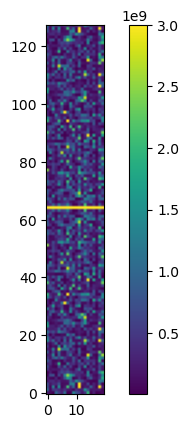

In [15]:
plt.imshow(spectrogram[:, :20], origin='lower', vmax=3e9)
plt.colorbar()
plt.show()